# Load Dataset

In [2]:
import numpy as np 
import pandas as pd

import seaborn as sns 
import matplotlib.pyplot as plt  

In [3]:
df = sns.load_dataset("titanic")
df.shape 

(891, 15)

In [4]:
df.columns 

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [5]:
# 필요없는 컬럼 제거
df.drop(
    ['class', 'embark_town', 'alive'], axis=1, inplace=True
)

df.shape 

(891, 12)

## Target

In [ ]:
# 각 class간의 비율 확인 
df['survived'].value_counts() / df.shape[0]

survived
0    0.616162
1    0.383838
Name: count, dtype: float64

## 평가 & 학습 데이터셋 

In [7]:
from sklearn.model_selection import train_test_split 

train, test = train_test_split(
    df, stratify=df['survived'], random_state=42
)

train.shape, test.shape 

((668, 12), (223, 12))

# EDA

In [8]:
train.info()

<class 'pandas.DataFrame'>
Index: 668 entries, 486 to 821
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    668 non-null    int64   
 1   pclass      668 non-null    int64   
 2   sex         668 non-null    str     
 3   age         537 non-null    float64 
 4   sibsp       668 non-null    int64   
 5   parch       668 non-null    int64   
 6   fare        668 non-null    float64 
 7   embarked    666 non-null    str     
 8   who         668 non-null    str     
 9   adult_male  668 non-null    bool    
 10  deck        145 non-null    category
 11  alone       668 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(3)
memory usage: 54.5 KB


# Data Preprocessing

## data cleaning

In [9]:
# row 중복 제거 
print(f"before: {train.shape}")

# 평가는 학습을 하는 데이터가 아니기 때문에 row 중복 제거 제외
train.drop_duplicates(inplace=True)
print(f"after: {train.shape}")

before: (668, 12)
after: (604, 12)


In [10]:
# 결측치 확인 및 제거 
null_tr = train.isnull().sum()

(null_tr[null_tr > 0] / train.shape[0]).sort_values(ascending=False)

deck        0.759934
age         0.142384
embarked    0.003311
dtype: float64

In [11]:
print(f"before: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

for tmp in [train, test]:
    null_tmp = tmp.isnull().sum()
    null_cols = null_tmp[null_tmp > 0].index

    for col in null_cols:
        try:
            tmp[col] = tmp[col].fillna(train[col].mean())

        except:
            tmp[col] = tmp[col].fillna(train[col].mode().values[0])

print(f"after: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

before: 547 / 211
after: 0 / 0


# Modeling

## Check Dataset before Modeling

In [17]:
assert train.isnull().sum().sum() == 0, "결측치가 존재합니다."
assert test.isnull().sum().sum() == 0, "결측치가 존재합니다."

assert train.shape[1] == test.shape[1], "컬럼 수가 다릅니다."

In [18]:
x_tr = train.drop(['survived'], axis=1)
y_tr = train['survived']
x_te = test.drop(['survived'], axis=1)
y_te = test['survived']

x_tr.shape, y_tr.shape, x_te.shape, y_te.shape 

((604, 11), (604,), (223, 11), (223,))

## Training

In [19]:
from lightgbm import LGBMClassifier, plot_importance

In [21]:
train.columns 

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'who', 'adult_male', 'deck', 'alone'],
      dtype='str')

In [23]:
cat_cols = [
    'pclass', 'sex', 'embarked', 'who', 'adult_male', 'deck', 'alone'
]

x_tr[cat_cols] = x_tr[cat_cols].astype('category')
x_te[cat_cols] = x_te[cat_cols].astype('category')

In [24]:
hp = {
    "random_state" : 42,
    "verbosity" : -1, # LightGBM 학습 로그 숨기기
    "n_jobs" : 1 # joblib CPU 코어 감지 경고 방지
}

lgb = LGBMClassifier(**hp).fit(x_tr, y_tr)

In [27]:
from sklearn.metrics import recall_score

# 훈련용 feature를 이용해서 target 예측 
y_pre_tr = lgb.predict(x_tr)
# target 예측(y_pre_tr)와 실제 데이터(y_tr)를 이용한 점수!
train_score = recall_score(y_tr, y_pre_tr)

# 평가용 feature를 이용해서 target 예측 
y_pre_te = lgb.predict(x_te)
# target 예측(y_pre_te)와 실제 데이터(y_te)를 이용한 점수!
test_score = recall_score(y_te, y_pre_te)

print(f'훈련용 평가지표: {train_score} / 테스트용 평가지표: {test_score}')

훈련용 평가지표: 0.9193548387096774 / 테스트용 평가지표: 0.6744186046511628


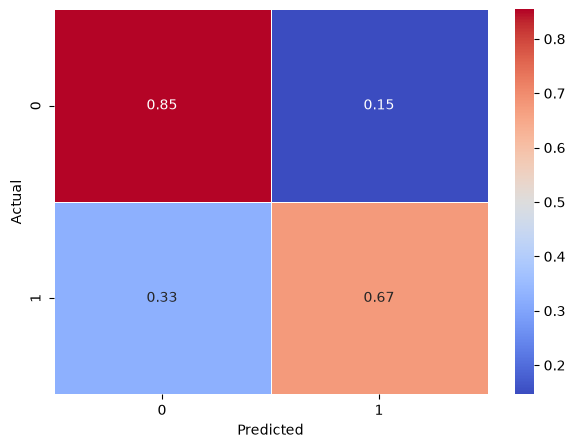

In [28]:
from sklearn.metrics import confusion_matrix

norm_conf_mx = confusion_matrix(y_te, y_pre_te, normalize="true")

plt.figure(figsize=(7,5))

sns.heatmap(norm_conf_mx, annot=True, cmap="coolwarm", linewidth=0.5)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()